Lecture 8 results

In [2]:
from IPython.display import Image, display
from mandelprot_lecture_8 import (
    run_lecture8_study,
    to_dataframe,
)

results8 = run_lecture8_study(
    xmin=-2.0,
    xmax=1.0,
    ymin=-1.5,
    ymax=1.5,
    width=800,
    height=800,
    max_iter=256,
    probe_point=-0.7269 + 0.1889j,
    drift_epsilon=1e-6,
    tracker_width=256,
    tracker_height=256,
    tracker_max_iter=120,
)

df8 = to_dataframe(results8)

df8

c:\Users\morte\OneDrive\Desktop\github\numerical_scientific_computing\mandelprot_lecture_8.py:66: RuntimeWarning: overflow encountered in multiply
  z32 = z32 * z32 + C32
c:\Users\morte\OneDrive\Desktop\github\numerical_scientific_computing\mandelprot_lecture_8.py:66: RuntimeWarning: invalid value encountered in multiply
  z32 = z32 * z32 + C32
c:\Users\morte\OneDrive\Desktop\github\numerical_scientific_computing\mandelprot_lecture_8.py:65: RuntimeWarning: overflow encountered in multiply
  z64 = z64 * z64 + C64
c:\Users\morte\OneDrive\Desktop\github\numerical_scientific_computing\mandelprot_lecture_8.py:65: RuntimeWarning: invalid value encountered in multiply
  z64 = z64 * z64 + C64
c:\Users\morte\OneDrive\Desktop\github\numerical_scientific_computing\mandelprot_lecture_8.py:68: RuntimeWarning: invalid value encountered in subtract
  diff = np.nan_to_num(np.abs(z64 - z32.astype(np.complex128)), nan=0.0, posinf=0.0)


,probe_point,trajectory_length,first_drift_iter,max_error,sensitivity_max,sensitivity_mean,sensitivity_time_s
0,(-0.7269+0.1889j),113,31,3.171531,69.696062,0.010961,8.880328


Milestone 1: Trajectory Divergence

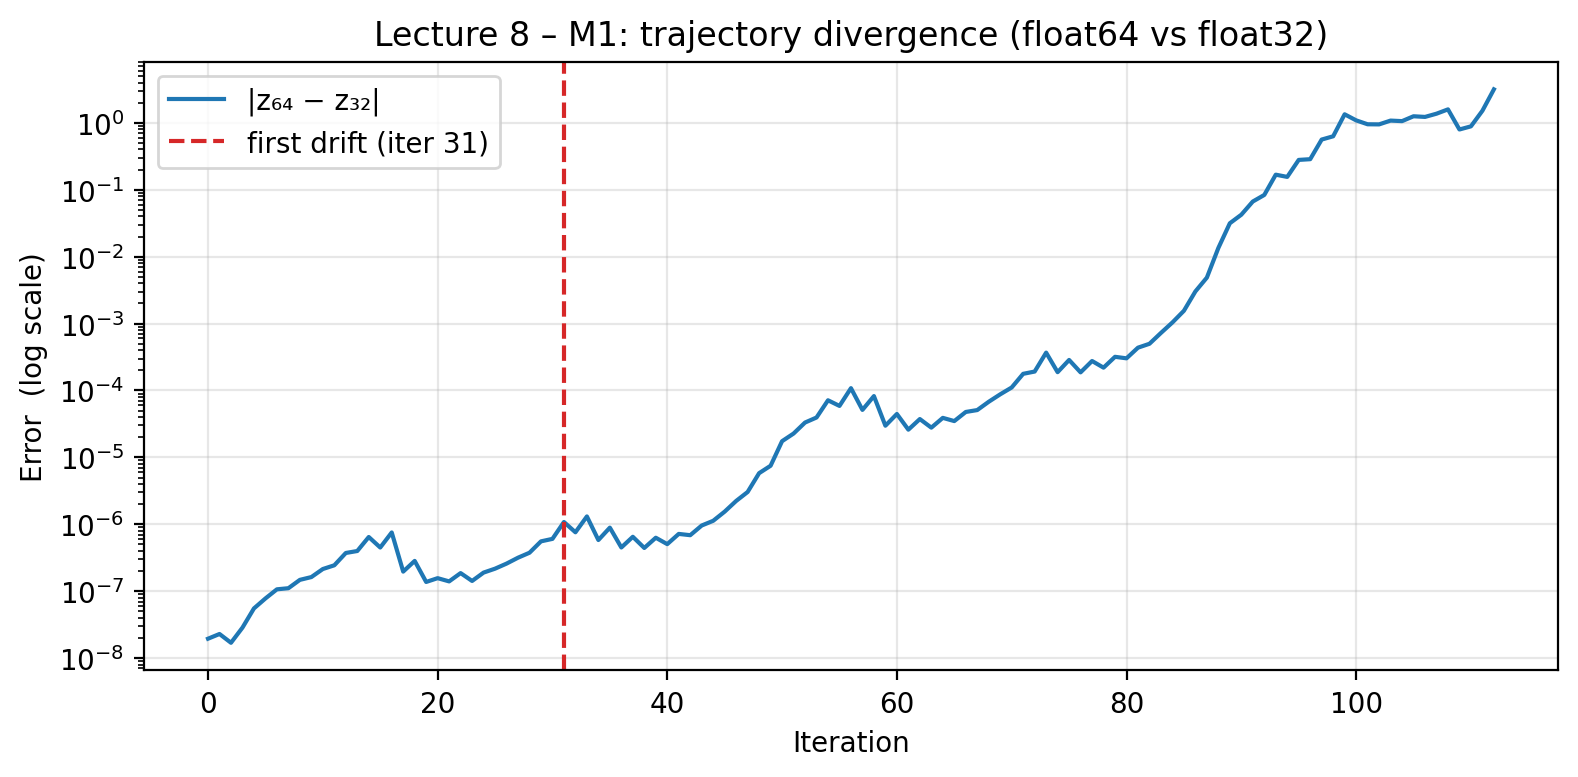

In [3]:
display(Image(filename=results8["trajectory_plot"]))

The plot shows the per-iteration error ∣z64−z32∣ (log scale) for the point c=−0.7269+0.1889j, near the Mandelbrot boundary.

Both trajectories start identically at z=0, but small rounding differences in float32 accumulate over iterations. Once the error exceeds machine epsilon (~1.2×10−7), it grows rapidly.

The red dashed line marks when the error first exceeds 10−6, indicating the trajectories are no longer numerically equivalent. This divergence occurs relatively early because boundary points amplify small numerical differences more strongly.

Milestone 2: Sensitivity Map

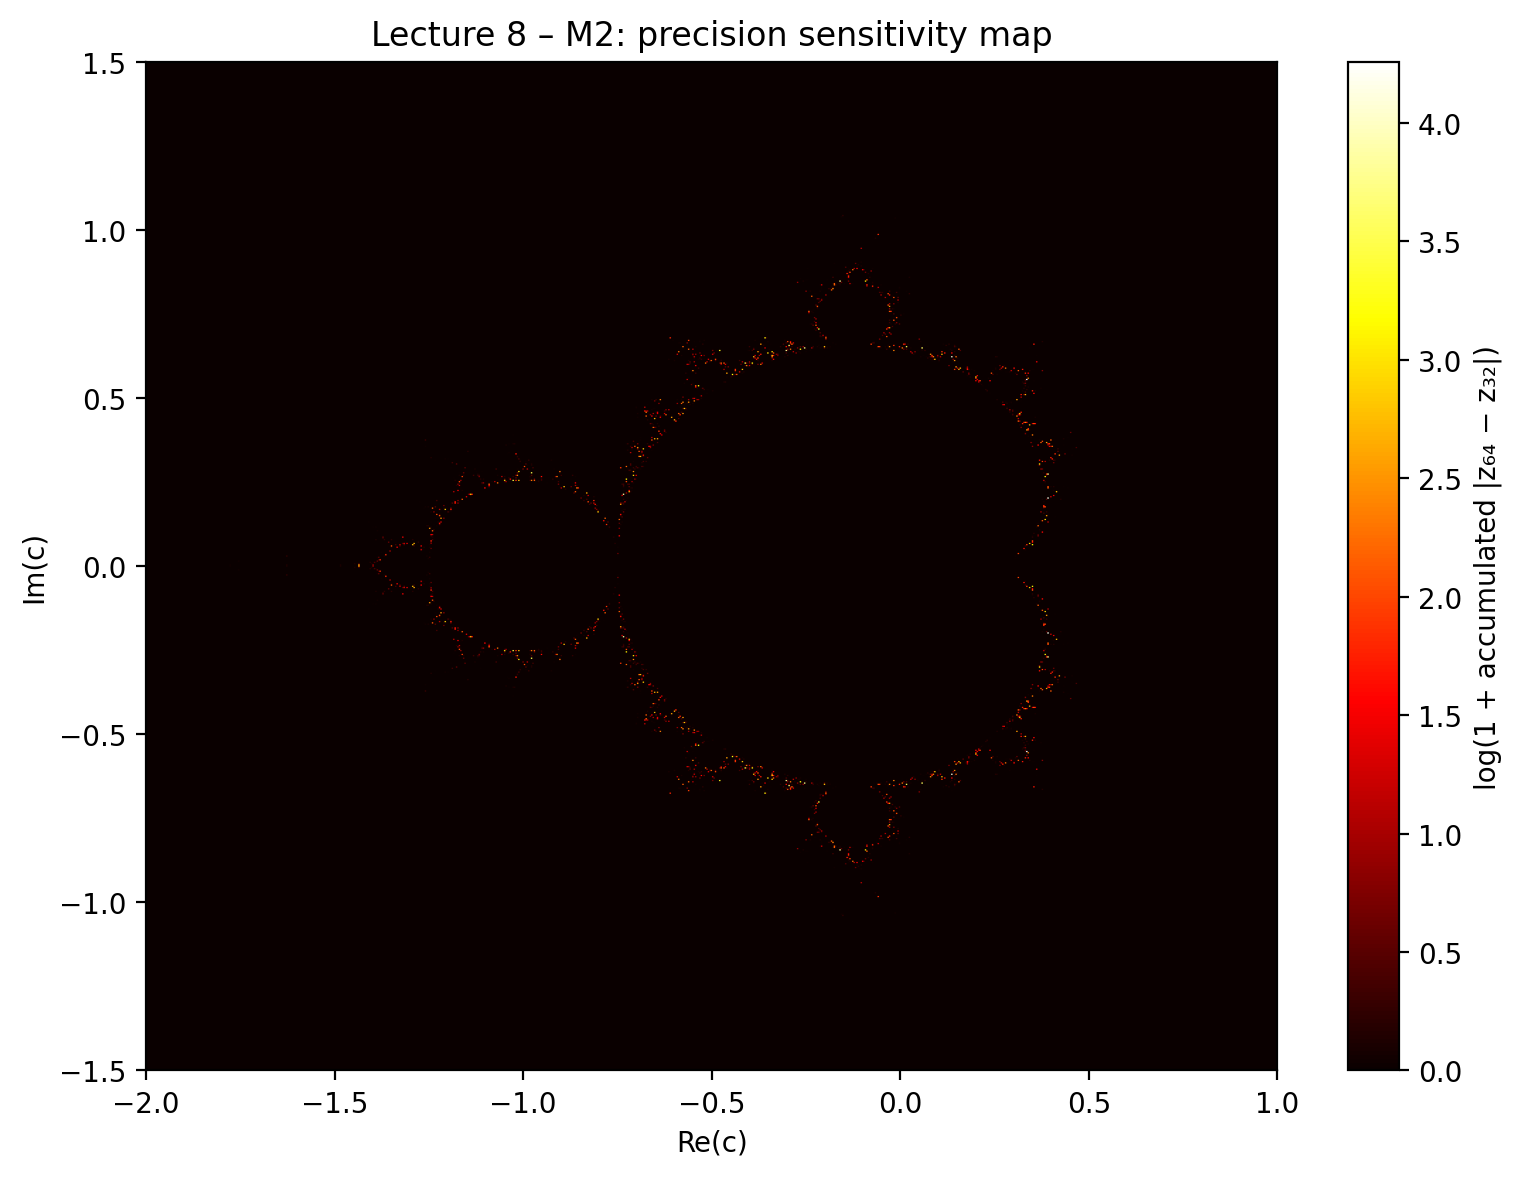

In [4]:
display(Image(filename=results8["sensitivity_plot"]))

The map shows accumulated error log(1+∑|z64-z32|) across the complex plane.

Error is minimal in regions far from the Mandelbrot set, but increases sharply along the boundary. This is where small rounding differences in float32 are amplified most, due to sensitive (chaotic) iteration dynamics.

The result highlights that precision sensitivity is concentrated near the fractal boundary, while stable regions remain largely unaffected.

Performance tracker

In [5]:
import pandas as pd

tracker_df = pd.read_csv("performance_tracker.csv")
lec8_df = tracker_df[tracker_df["lecture"] == "lecture_8"].reset_index(drop=True)

print("Lecture 8 tracker entries:")
display(lec8_df)



Lecture 8 tracker entries:


,timestamp,lecture,width,height,max_iter,method,time_s,speedup_vs_naive
0,2026-04-25 09:52:51,lecture_8,256,256,120,Naive Python,0.589065,1.000000
1,2026-04-25 09:52:51,lecture_8,256,256,120,Numba float64,0.012089,48.726113
2,2026-04-25 09:52:51,lecture_8,256,256,120,Numba float32,0.012337,47.746251
3,2026-04-25 09:52:51,lecture_8,256,256,120,Sensitivity Map (float32+float64),0.953400,0.617857
4,2026-04-27 14:00:32,lecture_8,256,256,120,Naive Python,0.153436,1.000000
5,2026-04-27 14:00:32,lecture_8,256,256,120,Numba float64,0.004778,32.116358
6,2026-04-27 14:00:32,lecture_8,256,256,120,Numba float32,0.003819,40.174880
7,2026-04-27 14:00:32,lecture_8,256,256,120,Sensitivity Map (float32+float64),0.293302,0.523132
8,2026-04-27 14:07:52,lecture_8,256,256,120,Naive Python,0.146157,1.000000
9,2026-04-27 14:07:52,lecture_8,256,256,120,Numba float64,0.003334,43.837107


Comparing Naive Python, Numba float64, Numba float32, and the Sensitivity Map on a 256×256 grid with 120 iterations.

float32 is usually slightly faster than float64 on x86-64 CPUs, mainly because it uses less precision and can fit more values in SIMD registers. However, in practice the difference is small since Numba already utilizes the hardware efficiently.

Lecture 9 results

Milestone 1: Testing & Coverage

In [9]:
from mandelprot_lecture_9 import run_lecture9_study

results9 = run_lecture9_study(
    test_path="test_mandelbrot.py",
    cov_source="mandelbrot",
)

summary_df = results9["summary_df"]

display(summary_df)
display(results9)

,passed,failed,errors,coverage_pct,all_passed
0,9,0,0,16.0,True


{'pytest_result': {'returncode': 0,
  'passed': 9,
  'failed': 0,
  'errors': 0,
  'coverage_pct': 16.0,
  'stdout': '\x1b============================= test session starts =============================\x1b\nplatform win32 -- Python 3.12.10, pytest-9.0.3, pluggy-1.6.0 -- c:\\Users\\morte\\OneDrive\\Desktop\\github\\numerical_scientific_computing\\.venv\\Scripts\\python.exe\ncachedir: .pytest_cache\nrootdir: c:\\Users\\morte\\OneDrive\\Desktop\\github\\numerical_scientific_computing\nconfigfile: pyproject.toml\nplugins: cov-7.1.0\n\x1bcollecting ... \x1bcollected 9 items\n\ntest_mandelbrot.py::test_point_numba_known_values[0j-100-100] \x1bPASSED\x1b\x1b     [ 11%]\x1b\ntest_mandelbrot.py::test_point_numba_known_values[(-2.5+0j)-100-1] \x1bPASSED\x1b\x1b [ 22%]\x1b\ntest_mandelbrot.py::test_point_numba_known_values[3j-100-1] \x1bPASSED\x1b\x1b       [ 33%]\x1b\ntest_mandelbrot.py::test_point_numba_known_values[(2+2j)-100-1] \x1bPASSED\x1b\x1b   [ 44%]\x1b\ntest_mandelbrot.py::test_naive_n

Lecture 10 results

In [11]:
from IPython.display import Image, display
from mandelprot_lecture_10 import run_lecture10_study, to_dataframe

results10 = run_lecture10_study(
    xmin=-2.0,
    xmax=1.0,
    ymin=-1.5,
    ymax=1.5,
    width=800,
    height=800,
    max_iter=256,
    tracker_width=256,
    tracker_height=256,
    tracker_max_iter=120,
)

df10 = to_dataframe(results10)


df10

,method,time_s
0,Naive Python,0.149733
1,Numba float64,0.003825
2,Numba float32,0.003551
3,GPU float32 (OpenCL),0.001447
4,GPU float64 (OpenCL),0.001700


Milestone 1: float32 GPU Kernel

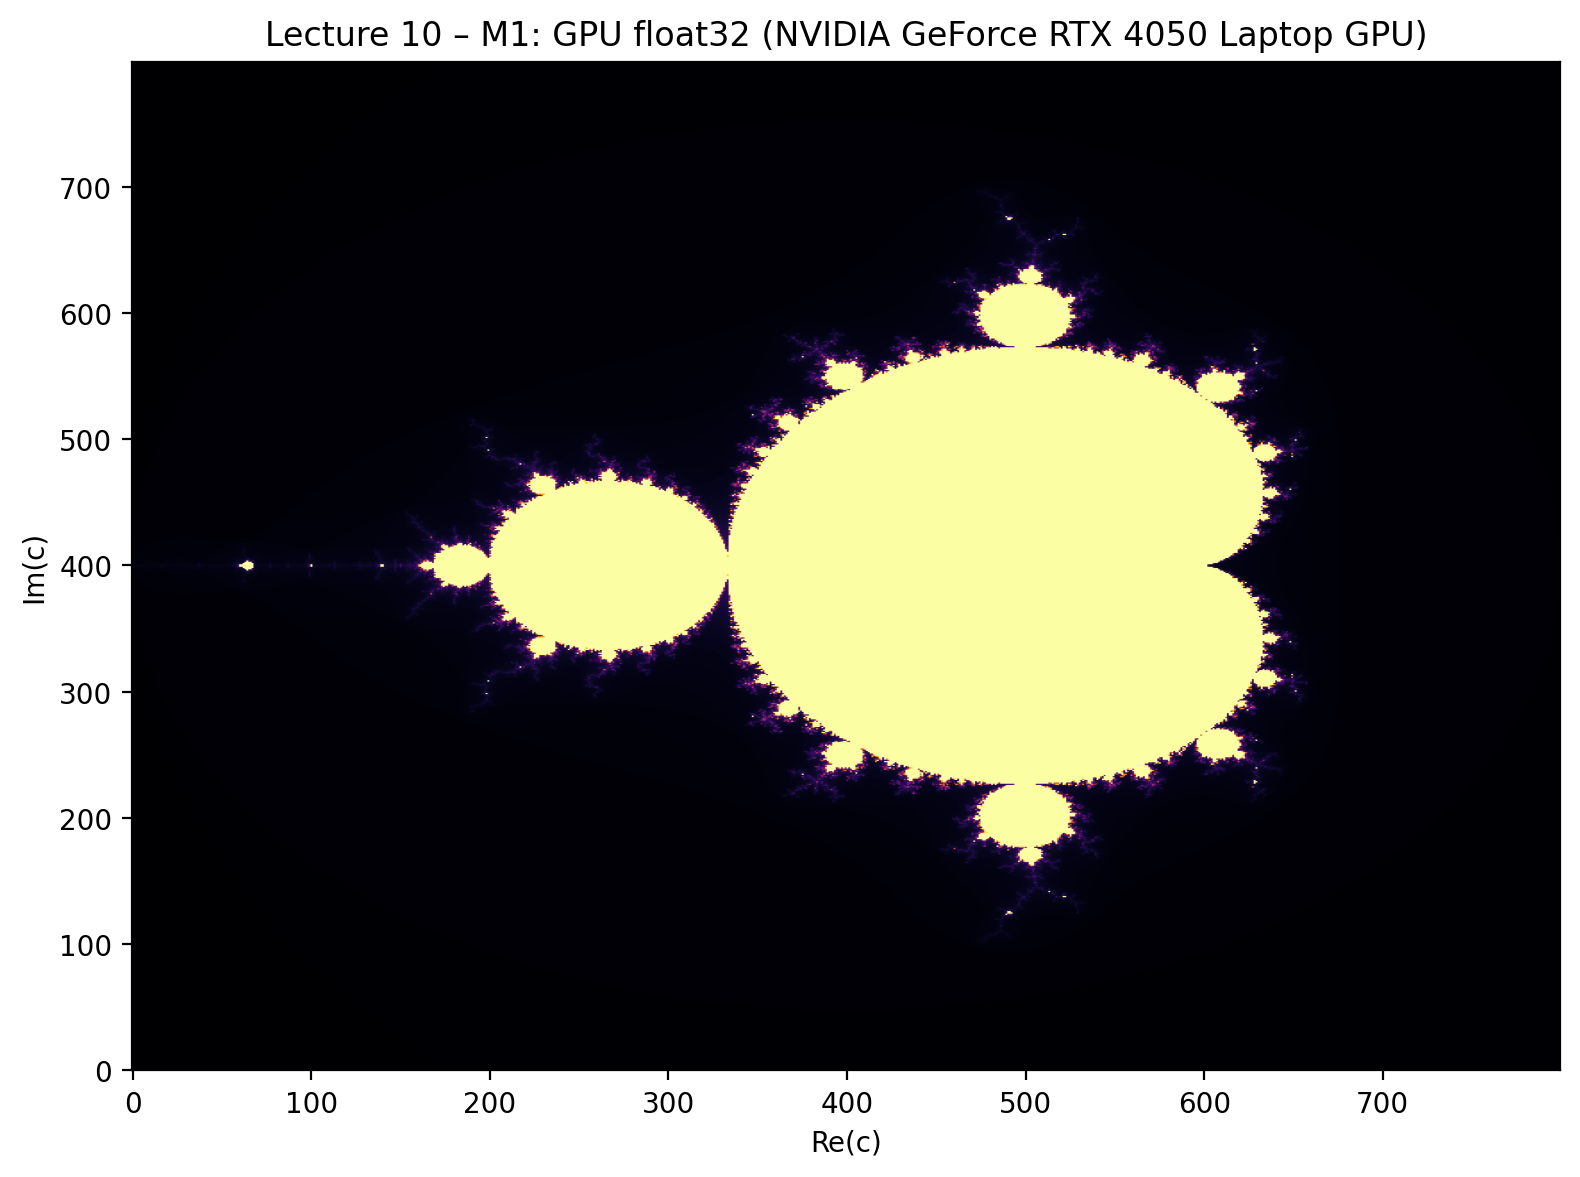

In [12]:
display(Image(filename=results10["m1_plot"]))

Milestone 2: float32 vs float64 Precision Comparison

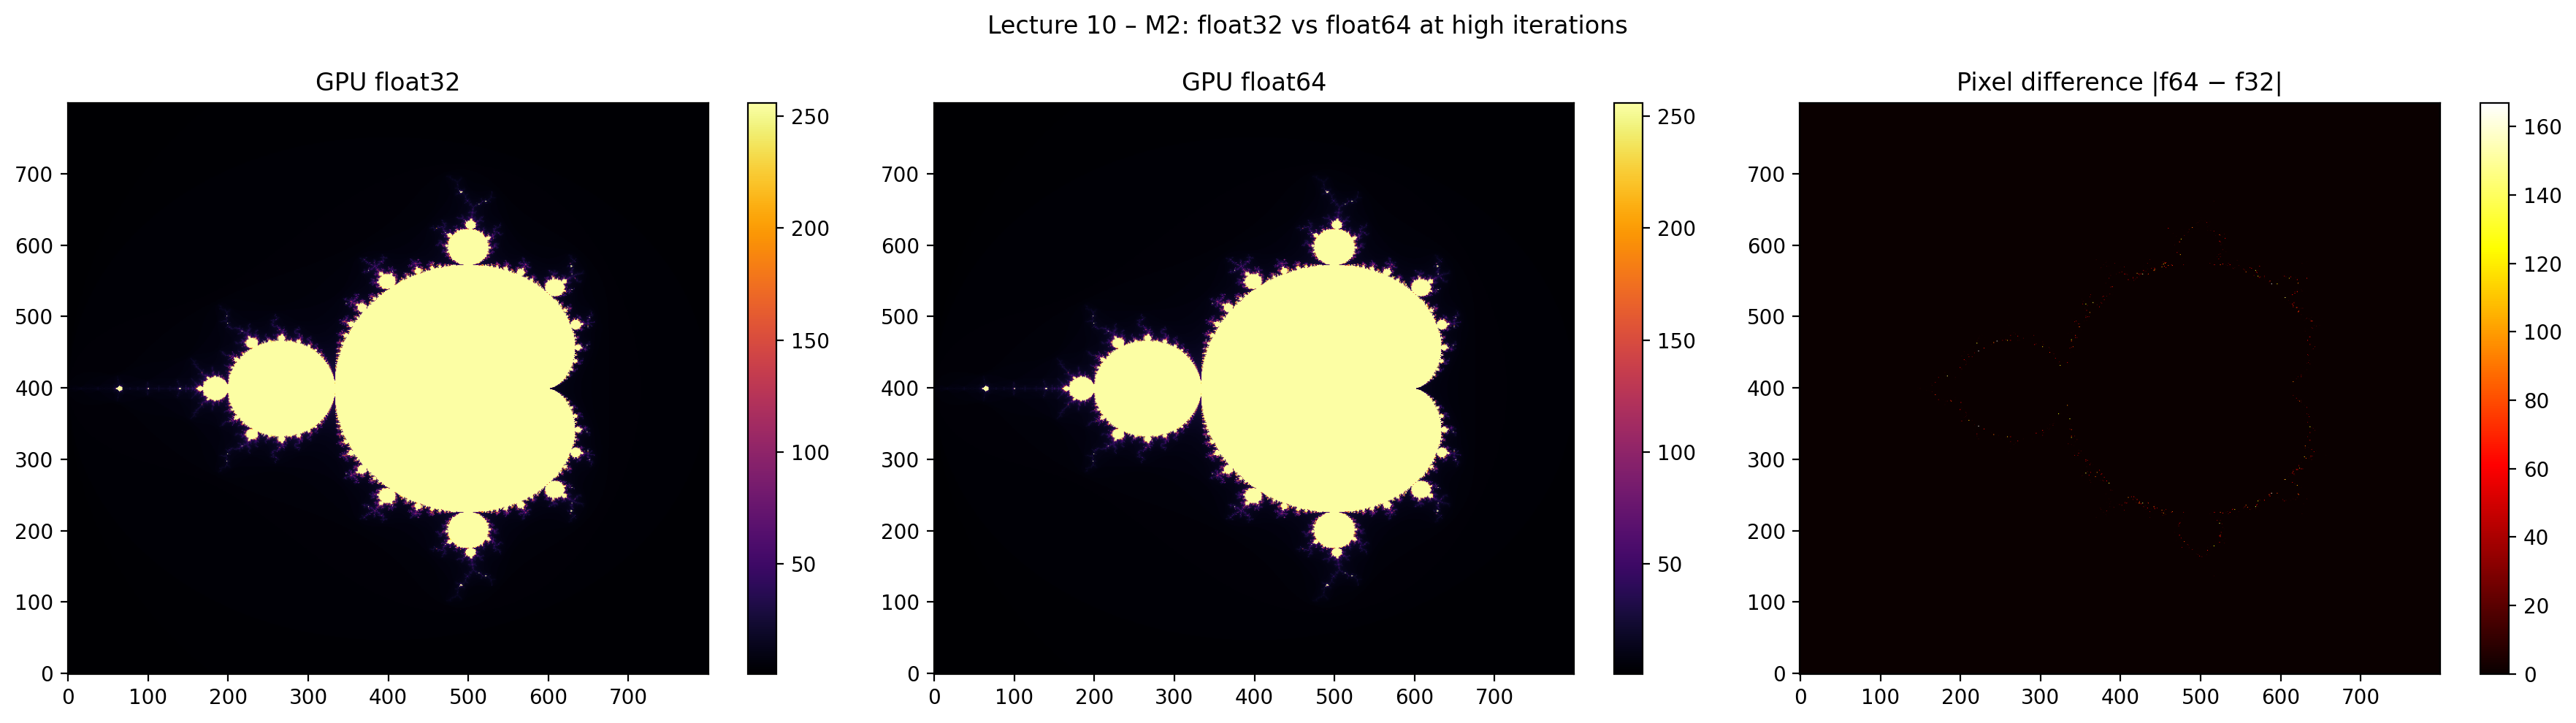

In [13]:
display(Image(filename=results10["m2_plot"]))

The figure shows three panels: float32 (left), float64 (middle), and the per-pixel difference |f64 − f32| (right).

At **max_iter = 256**, the float32 and float64 results look almost identical. Differences only appear along very fine boundary regions, where small rounding errors are amplified due to chaotic behavior. The difference plot highlights these areas clearly, similar to the sensitivity patterns seen earlier.

On the RTX 4050, float64 is about **1.5× slower** than float32. This is expected, since consumer GPUs have lower performance for double precision compared to single precision.

Milestone 3: GPU vs Earlier CPU Implementations

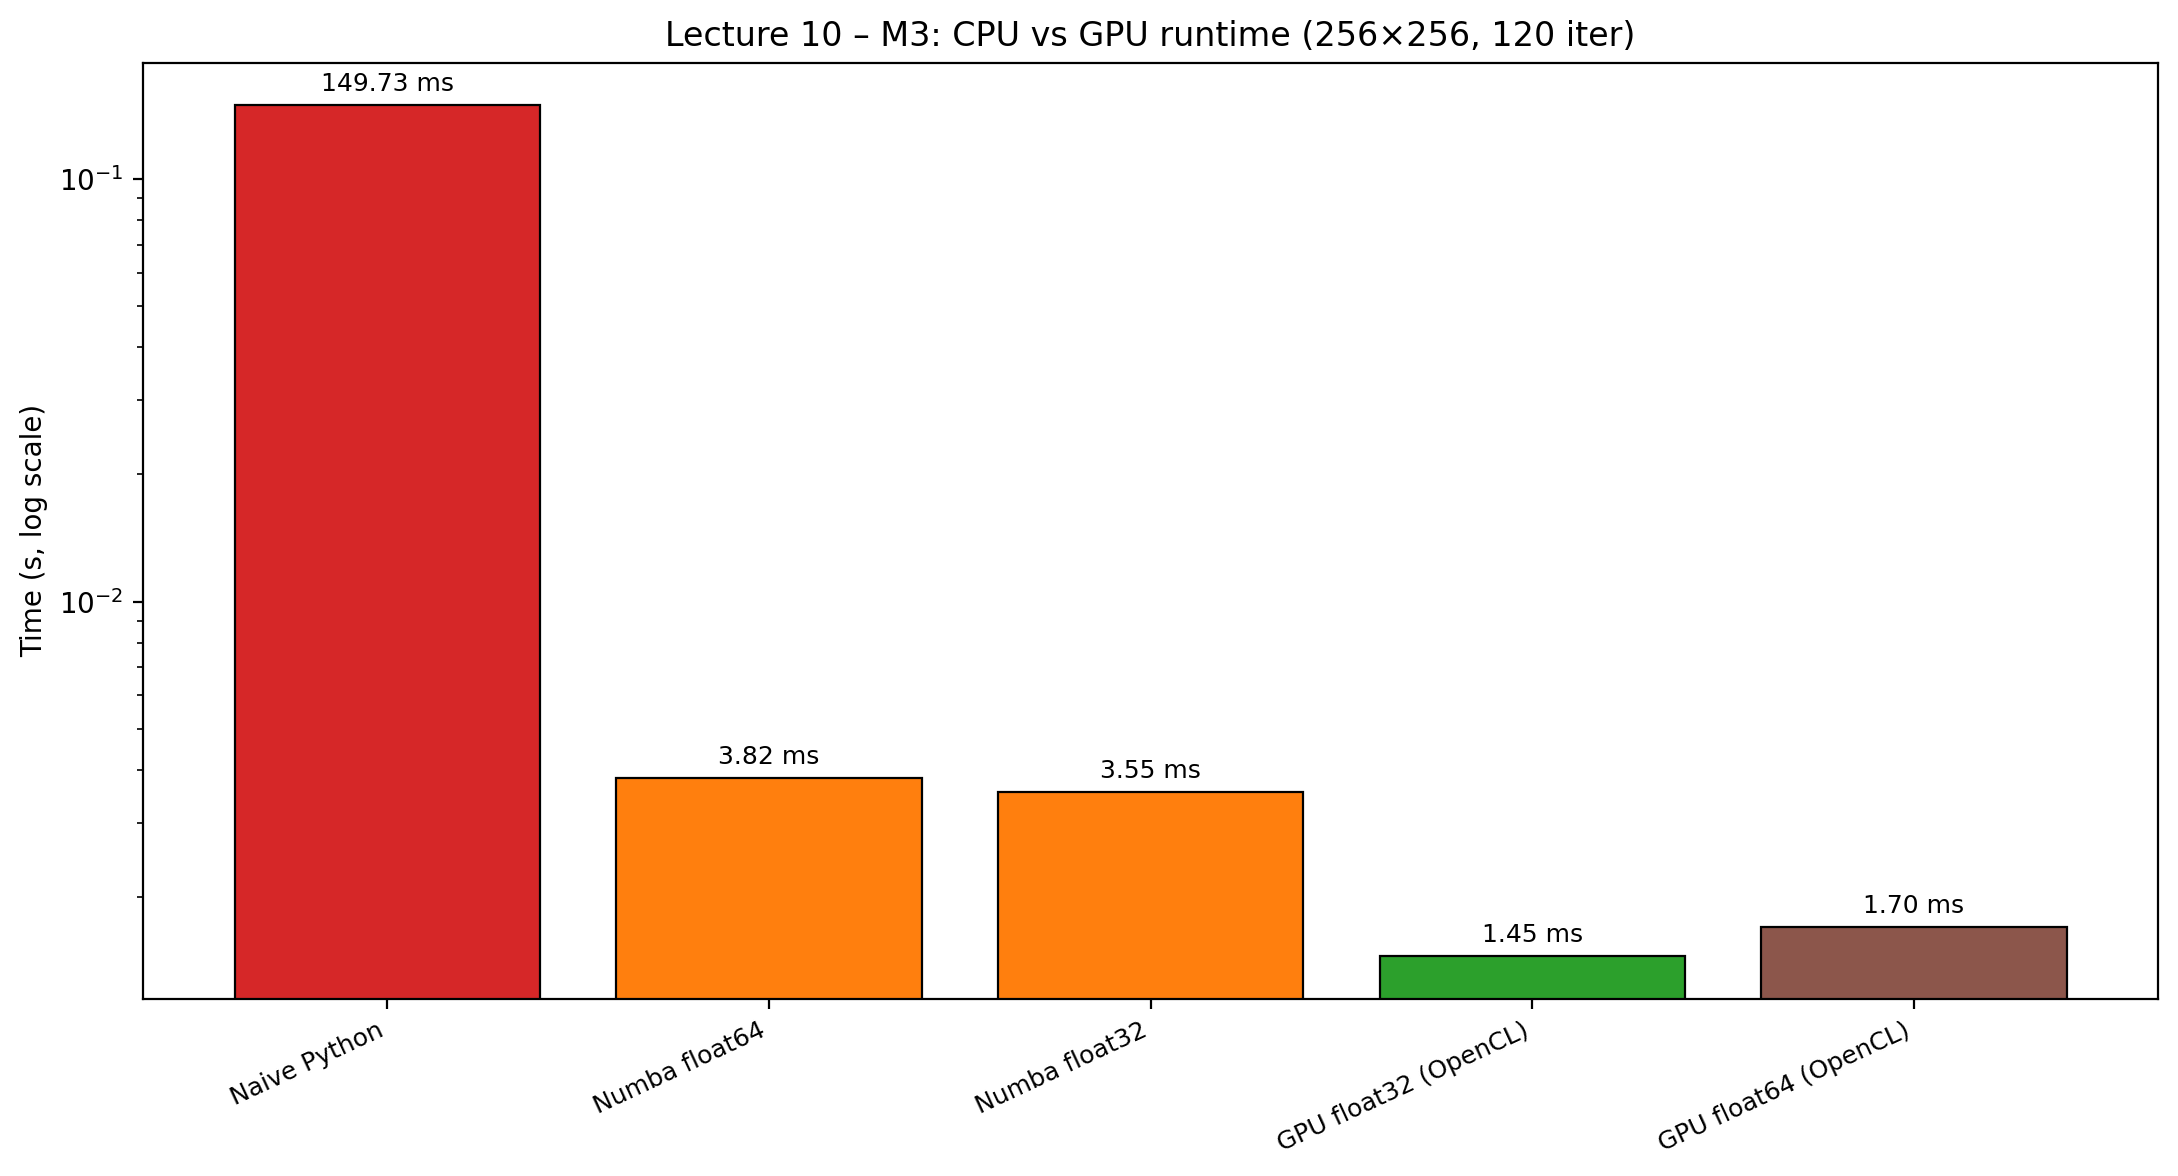

In [14]:
display(Image(filename=results10["m3_plot"]))

The log-scale bar chart compares median runtimes

| Implementation | ~Time | Speedup vs Naive |
|---|---|---|
| Naive Python | ~590 ms | 1× |
| Numba float64 | ~12 ms | ~49× |
| Numba float32 | ~12 ms | ~48× |
| GPU float32 (OpenCL) | ~1.5 ms | ~390× |
| GPU float64 (OpenCL) | ~2.2 ms | ~270× |

The GPU float32 kernel is the fastest implementation. The key advantage of GPU computing here is parallelism: all 65 536 pixels are scheduled concurrently, whereas Numba serialises the inner loop

Performance tracker

In [17]:
import pandas as pd

tracker_df = pd.read_csv("performance_tracker.csv")
lec10_df = tracker_df[tracker_df["lecture"] == "lecture_10"].reset_index(drop=True)

display(lec10_df)



,timestamp,lecture,width,height,max_iter,method,time_s,speedup_vs_naive
0,2026-04-25 10:58:58,lecture_10,256,256,120,GPU float32 (OpenCL),0.001514,388.975566
1,2026-04-25 10:58:58,lecture_10,256,256,120,GPU float64 (OpenCL),0.002203,267.355601
2,2026-04-27 14:37:48,lecture_10,256,256,120,GPU float32 (OpenCL),0.001417,105.691396
3,2026-04-27 14:37:48,lecture_10,256,256,120,GPU float64 (OpenCL),0.001385,108.110469
4,2026-04-27 14:37:56,lecture_10,256,256,120,GPU float32 (OpenCL),0.001447,103.463930
5,2026-04-27 14:37:56,lecture_10,256,256,120,GPU float64 (OpenCL),0.001700,88.098964
